In [29]:
import numpy as np
from sklearn.metrics import accuracy_score
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [2]:
from keras.datasets import mnist
(x_train, y_train),(x_test, y_test) = mnist.load_data()

In [3]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size = 0.2, random_state = 42)

In [4]:
print("x_train [shape %s] sample patch: \n" % str(x_train.shape), x_train[1, 15:20, 5:10])

x_train [shape (48000, 28, 28)] sample patch: 
 [[  0  77 254 154   0]
 [  0 145 253  96   0]
 [  0 254 238  37   0]
 [  0 254 229   0   0]
 [  0 254 246  69   0]]


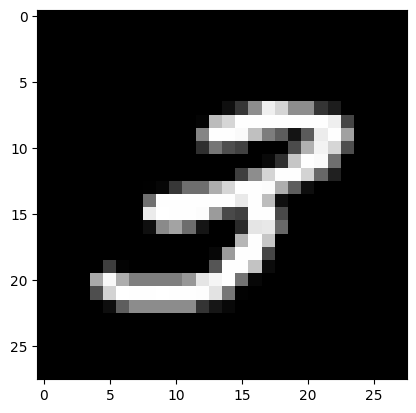

In [5]:
import matplotlib.pyplot as plt

plt.imshow(x_train[5], cmap = 'gray')
plt.show()

In [6]:
from keras.datasets import mnist
(x_train, y_train),(x_test, y_test) = mnist.load_data()

#preprocessing data - scale the pixel values to the range [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

#reshape the data to fit the model input
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

#one-hot encode the labels
y_train_one_hot = tf.keras.utils.to_categorical(y_train, num_classes = 10)
y_test_one_hot = tf.keras.utils.to_categorical(y_test, num_classes = 10)

#create some of hidden layers and the output layer
model = tf.keras.Sequential([
    tf.keras.layers.Dense(500, activation='sigmoid', input_shape=(784,)),
    tf.keras.layers.Dense(100, activation='sigmoid'),
    tf.keras.layers.Dense(10, activation='softmax'),  
])

model.summary()

c:\Users\Lenovo\Desktop\DEPI(R_2)\ML_git\GIZ4_AIS2_S1_Ml\.env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        50,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 443,610 (1.69 MB)

 Trainable params: 443,610 (1.69 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train_one_hot, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8693 - loss: 0.4962 - val_accuracy: 0.9312 - val_loss: 0.2347
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9387 - loss: 0.2081 - val_accuracy: 0.9482 - val_loss: 0.1740
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9556 - loss: 0.1475 - val_accuracy: 0.9635 - val_loss: 0.1288
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9673 - loss: 0.1107 - val_accuracy: 0.9662 - val_loss: 0.1137
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9747 - loss: 0.0846 - val_accuracy: 0.9696 - val_loss: 0.1014
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9803 - loss: 0.0649 - val_accuracy: 0.9684 - val_loss: 0.0972
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9856 - loss: 0.0501 - val_accuracy: 0.9741 - val_loss: 0.0839
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9888 - loss: 0.0386 - val_accuracy: 0

the dropout is help me to reduce overfit and reactivate nodes that isn't working so make it to work

In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test_one_hot)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9783 - loss: 0.0662
Test accuracy: 0.9782999753952026


In [9]:
def get_random_indices(total_images, num_images):
    return np.random.choice(total_images, num_images, replace=False)

#make predictions
predictions = model.predict(x_test)

x_test_images = x_test.reshape(-1,28,28)

prediction_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test_one_hot, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


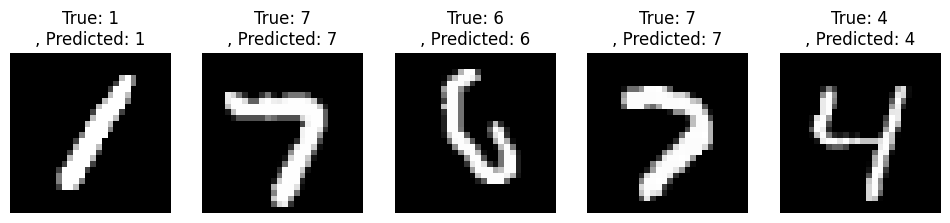

In [10]:
num_images = 5
random_indices = get_random_indices(len(x_test_images) , num_images)


def plot_images(images , labels , predictions):
    plt.figure(figsize=(12,8))
    for i in range(len(images)):
        plt.subplot(1 , len(images) , i+1)
        plt.imshow(images[i] , cmap='grey')
        plt.title(f"True: {labels[i]}\n, Predicted: {predictions[i]}")
        plt.axis('off')
    plt.show()

plot_images(x_test_images[random_indices] , true_classes[random_indices] , prediction_classes[random_indices])

In [11]:
from keras.datasets import mnist
from keras.callbacks import TensorBoard

NAME = 'mnist-28-28-v1'
TensorBoard = TensorBoard(log_dir='logs/{}'.format(NAME))

(x_train, y_train), (x_test, y_test) = mnist.load_data()
#preprocessing data - scale the data
x_train = x_train.astype('float32') /255.0
x_test = x_test.astype('float32') /255.0
#reshape data
x_train = x_train.reshape(-1,784)
x_test = x_test.reshape(-1,784)
#one hot encoding
y_train_oh = tf.keras.utils.to_categorical(y_train, 10)
y_test_oh = tf.keras.utils.to_categorical(y_test, 10)
model = tf.keras.Sequential([
    #creatae some of hidden layers
    tf.keras.layers.Dense(500, activation='sigmoid', input_shape=(784,)),
    tf.keras.layers.Dense(100, activation='sigmoid'),
    tf.keras.layers.Dense(10, activation='softmax')                        
])
model.compile(optimizer= 'Adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train_oh, epochs=10, batch_size=64, validation_split=0.2, callbacks=[TensorBoard])
test_loss, test_acc = model.evaluate(x_test, y_test_oh)
print('Test accuracy:', test_acc)
#

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8734 - loss: 0.4909 - val_accuracy: 0.9292 - val_loss: 0.2414
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9384 - loss: 0.2069 - val_accuracy: 0.9508 - val_loss: 0.1702
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9563 - loss: 0.1468 - val_accuracy: 0.9600 - val_loss: 0.1343
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9667 - loss: 0.1107 - val_accuracy: 0.9682 - val_loss: 0.1130
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9760 - loss: 0.0832 - val_accuracy: 0.9703 - val_loss: 0.0987
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9811 - loss: 0.0643 - val_accuracy: 0.9742 - val_loss: 0.0875
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9855 - loss: 0.0499 - val_accuracy: 0.9721 - val_loss: 0.0944
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9885 - loss: 0.0388 - val_accuracy:

In [ ]:
%tensorboard --logdir=logs/ --port=6006

ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\Lenovo\Desktop\DEPI(R_2)\ML_git\GIZ4_AIS2_S1_Ml\.env\Scripts\tensorboard.exe\__main__.py", line 4, in <module>
  File "C:\Users\Lenovo\Desktop\DEPI(R_2)\ML_git\GIZ4_AIS2_S1_Ml\.env\Lib\site-packages\tensorboard\main.py", line 27, in <module>
    from tensorboard import default
  File "C:\Users\Lenovo\Desktop\DEPI(R_2)\ML_git\GIZ4_AIS2_S1_Ml\.env\Lib\site-packages\tensorboard\default.py", line 30, in <module>
    import pkg_resources
ModuleNotFoundError: No module named 'pkg_resources'

In [33]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import TensorBoard

list_activity = ['sigmoid', 'relu', 'tanh']
list_optimizer = ['Adam', 'SGD', 'RMSprop']
list_loss = ['categorical_crossentropy', 'mean_squared_error']

(x_train, y_train), (x_test, y_test) = mnist.load_data()
#preprocessing data - scale the data
x_train = x_train.astype('float32') /255.0
x_test = x_test.astype('float32') /255.0
#reshape data
x_train = x_train.reshape(-1,784)
x_test = x_test.reshape(-1,784)
#one hot encoding
y_train_oh = tf.keras.utils.to_categorical(y_train, 10)
y_test_oh = tf.keras.utils.to_categorical(y_test, 10)

i = 1
accuracy_scores = []
for activity in list_activity:
    for optimizer in list_optimizer:
            NAME = f'mnist-28-28-{i}'
            Tensorboard = TensorBoard(log_dir='./logs/{}'.format(NAME))


            model = tf.keras.Sequential([
                #creatae some of hidden layers
                tf.keras.layers.Dense(500, activation = activity, input_shape=(784,)),
                tf.keras.layers.Dense(100, activation = activity),
                tf.keras.layers.Dense(10, activation='softmax')                        
            ])
            model.compile(optimizer= optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
            history = model.fit(x_train, y_train_oh, epochs=10, batch_size=64, validation_split=0.2, callbacks=[Tensorboard])
            test_loss, test_acc = model.evaluate(x_test, y_test_oh)
            print('Test accuracy:', test_acc)

            i += 1

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8720 - loss: 0.4848 - val_accuracy: 0.9307 - val_loss: 0.2309
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9392 - loss: 0.2057 - val_accuracy: 0.9488 - val_loss: 0.1771
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9570 - loss: 0.1449 - val_accuracy: 0.9595 - val_loss: 0.1384
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9690 - loss: 0.1073 - val_accuracy: 0.9672 - val_loss: 0.1135
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9758 - loss: 0.0815 - val_accuracy: 0.9705 - val_loss: 0.0969
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9807 - loss: 0.0640 - val_accuracy: 0.9726 - val_loss: 0.0920
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9862 - loss: 0.0481 - val_accuracy: 0.9730 - val_loss: 0.0877
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9891 - loss: 0.0385 - val_accuracy